## Análisis Comparativo: QuadTree vs Fuerza Bruta

Para medir el rendimiento real de ambos enfoques se ejecutaron pruebas sobre conjuntos de puntos que van desde **1.000 hasta 200.000 puntos**, midiendo el tiempo promedio en milisegundos de la búsqueda por radio y KNN con k=5.

### Comportamiento general

Las gráficas de Radio y KNN están en escala logarítmica, lo que permite apreciar claramente que **la fuerza bruta crece de forma sostenida** con cada aumento de $n$, mientras que el QuadTree se estabiliza rápidamente. A 200.000 puntos, la fuerza bruta tarda aproximadamente **10× más** que el QuadTree tanto en radio como en KNN, lo que confirma empíricamente la diferencia teórica entre $O(n)$ y $O(\log n + k)$.

### Donde gana el fuerza bruta

La gráfica de divergencia con zoom hasta $n = 10.000$ permite identificar con precisión el **punto de cruce experimental**, detectado en aproximadamente $n \approx 150$ puntos. Por debajo de ese umbral, el QuadTree es más lento que la fuerza bruta debido al costo fijo de construir el árbol y recorrer su estructura. A partir de ese punto, la poda de cuadrantes empieza a rendir frutos y el QuadTree toma ventaja de forma sostenida.

Esto tiene una explicación: con pocos puntos, recorrer una lista es tan rápido que la sobrecarga de la recursión del árbol no se justifica. Con muchos puntos, descartar ramas enteras del espacio ahorra una cantidad creciente de comparaciones, y esa ventaja se acumula con cada consulta.

### Estabilidad del QuadTree

Un detalle notable en las gráficas es que el tiempo del QuadTree para KNN **permanece casi plano** conforme crece $n$, con valores por debajo de 0.1 ms incluso a 200.000 puntos. Esto se debe a que la búsqueda de vecinos cercanos recorre únicamente los nodos que podrían mejorar el mejor candidato encontrado hasta el momento, podando agresivamente el árbol a medida que el heap se llena con buenos vecinos.

A diferencia de la busqueda por radio, que puede requerir revisar más nodos si el radio es grande o si los puntos están densamente agrupados, la búsqueda KNN se beneficia enormemente de la estructura del QuadTree, manteniendo tiempos de respuesta extremadamente bajos incluso con grandes cantidades de datos.

Mientra que fuerza bruta muestra un crecimiento lineal claro, el QuadTree demuestra su eficiencia y escalabilidad, validando su uso para aplicaciones con grandes conjuntos de puntos geoespaciales donde la rapidez de consulta es crucial.

 listo n=10
 listo n=400
 listo n=1000
 listo n=5000
 listo n=10000
 listo n=25000
 listo n=50000
 listo n=100000
 listo n=200000


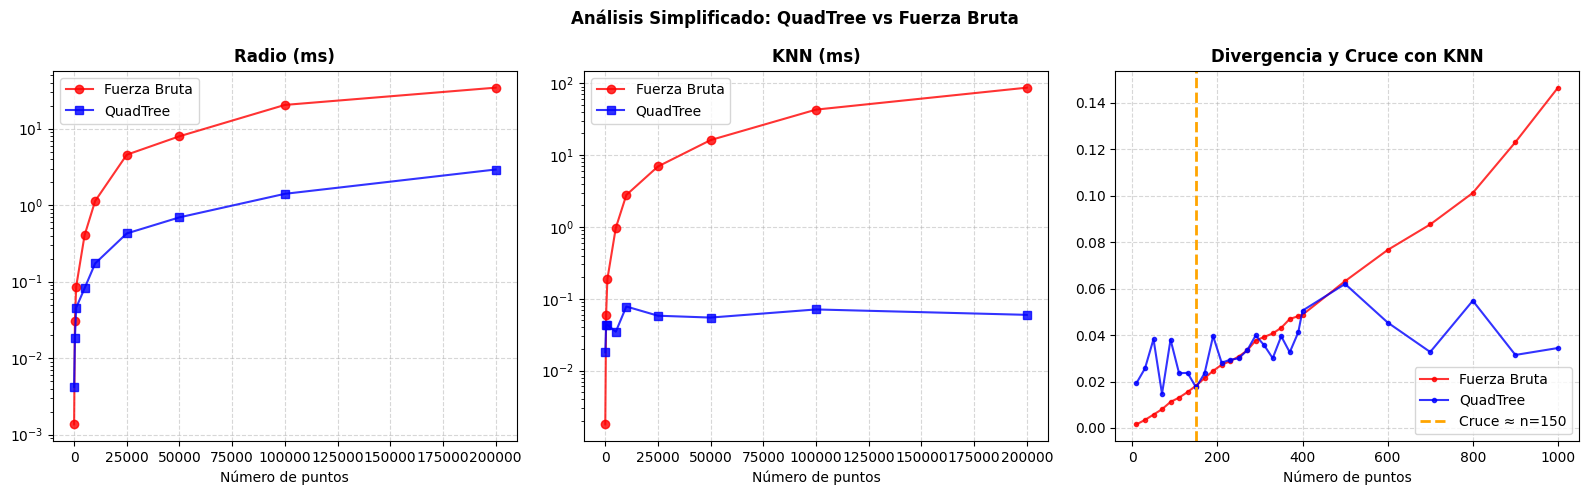

In [29]:
%run QuadTrees.ipynb
import math
import numpy as np
import matplotlib.pyplot as plt
import time

"""Funciones de busqueda de fuerza bruta para comparar con QuadTree"""
def buscar_radio_bruta(puntos, centro, radio):
    return [p for p in puntos if math.dist(p, centro) <= radio]

"""Función de búsqueda KNN de fuerza bruta para comparar con QuadTree"""
def buscar_knn_bruta(puntos, centro, k):
    return sorted(puntos, key=lambda p: math.dist(p, centro))[:k]

"""Función para medir el tiempo de ejecución de una función dada, con un número específico de repeticiones para obtener un promedio"""
def medir(fn, repeticiones=10):
    t0 = time.perf_counter()
    for _ in range(repeticiones): fn()
    return (time.perf_counter() - t0) * 1000 / repeticiones

"""funcion para ejecutar las pruebas entre quadtree y fuerza bruta para radio y KNN como pequeños y grandes tamaños de n"""
def ejecutar_pruebas():
    tam_grandes = [10, 400, 1000, 5000, 10000, 25000, 50000, 100000, 200000]

    #saltos largos hasta 1k para ver la separación
    tam_peq = list(range(10, 400, 20)) + list(range(400, 1001, 100))


    res = {'r_bruta': [], 'r_quad': [], 'k_bruta': [], 'k_quad': []}
    cruce_b, cruce_q = [], []

    for n in tam_grandes:
        pts = [tuple(p) for p in np.random.uniform(0, 10000, (n, 2))]
        centro = tuple(np.random.uniform(1000, 9000, 2))
        arbol = QuadTree(pts)

        res['r_bruta'].append(medir(lambda: buscar_radio_bruta(pts, centro, 500)))
        res['r_quad'].append(medir(lambda: list(arbol.buscar_en_radio(arbol.raiz, centro, 500))))
        res['k_bruta'].append(medir(lambda: buscar_knn_bruta(pts, centro, 5)))
        res['k_quad'].append(medir(lambda: arbol.buscar_vecinos_cercanos(centro, 5)))
        print(f" listo n={n}")

    for n in tam_peq:
        pts = [tuple(p) for p in np.random.uniform(0, 10000, (n, 2))]
        centro = tuple(np.random.uniform(1000, 9000, 2))
        arbol = QuadTree(pts)
        k_real = min(5, n)

        # Hacemos menos repeticiones en N grandes para no hacer tan lenta la prueba
        reps = 30 if n < 1000 else 10
        cruce_b.append(medir(lambda: buscar_knn_bruta(pts, centro, k_real), reps))
        cruce_q.append(medir(lambda: arbol.buscar_vecinos_cercanos(centro, k_real), reps))

    # Detectar el punto de cruce matemático
    cruce_n = None
    for i in range(len(tam_peq) - 1):
        if cruce_q[i] > cruce_b[i] and cruce_q[i+1] <= cruce_b[i+1]:
            cruce_n = tam_peq[i+1]
            break

    return tam_grandes, res, tam_peq, cruce_b, cruce_q, cruce_n
"""Ejecutamos las pruebas y graficamos los resultados, mostrando claramente la diferencia entre QuadTree y Fuerza Bruta en términos de tiempo de ejecución para búsquedas por radio y KNN, con un análisis visual del punto de cruce donde QuadTree comienza a ser más eficiente que la fuerza bruta."""
if __name__ == "__main__":
    tg, res, tp, cb, cq, cruce_n = ejecutar_pruebas()

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("Análisis Simplificado: QuadTree vs Fuerza Bruta", fontweight="bold")

    # Gráficas grandes en escala logarítmica
    for ax, k_b, k_q, titulo in zip([ax1, ax2], ['r_bruta', 'k_bruta'], ['r_quad', 'k_quad'], ["Radio (ms)", "KNN (ms)"]):
        ax.plot(tg, res[k_b], '-ro', label="Fuerza Bruta", alpha=0.8)
        ax.plot(tg, res[k_q], '-bs', label="QuadTree", alpha=0.8)
        ax.set_yscale("log")
        ax.set_title(titulo, fontweight="bold")

    # Gráfica del punto de cruce (hasta 1k)
    ax3.plot(tp, cb, '-r', marker='.', label="Fuerza Bruta", alpha=0.8)
    ax3.plot(tp, cq, '-b', marker='.', label="QuadTree", alpha=0.8)

    # Dibujar la línea del punto de cruce si se detectó
    if cruce_n:
        ax3.axvline(cruce_n, color="orange", linestyle="--", linewidth=2, label=f"Cruce ≈ n={cruce_n}")

    ax3.set_title("Divergencia y Cruce con KNN", fontweight="bold")

    # Aplicar formato a todas
    for ax in (ax1, ax2, ax3):
        ax.set_xlabel("Número de puntos")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()